## Adversarial validation, PSI/KS таблица

# 02 — Диагностика дрейфа (train / val / holdout)

**Цель** (требование ТЗ): явно проанализировать дрейф — какие признаки
смещаются между train, val и holdout, какова величина сдвига.

**Методы**:
1. Adversarial validation train-vs-val и train-vs-holdout (по X).
2. Feature importance adversarial → какие фичи дрейфуют.
3. PSI / KS по каждой фиче между срезами.
4. Проверка MONTH_COUNT на leak (аналог n_days из Rossmann-практики).

Дрейф здесь заложен организаторами намеренно → ждём AUC заметно выше 0.5.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import matplotlib.pyplot as plt

In [2]:
NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_DIR / 'data'

In [3]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"NOTEBOOK_DIR: {NOTEBOOK_DIR}")
print(f"DATA_DIR: {DATA_DIR}")

NOTEBOOK_DIR: /Users/alexey_macos/Documents/ITjob/Pet-projects/Magnit_retailhack_2026/notebooks
DATA_DIR: /Users/alexey_macos/Documents/ITjob/Pet-projects/Magnit_retailhack_2026/data


In [4]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(r"\s+", "", regex=True)
                         .str.replace(",", ".", regex=False), errors="coerce")

def read_data(path):
    df = (pd.read_csv(path, encoding="utf-8-sig", skipinitialspace=True)
            .rename(columns=lambda c: c.strip().upper()))
    for col in df.columns:
        if df[col].dtype != "object":
            continue
        converted = clean_numeric(df[col])
        if (converted.isna().sum() - df[col].isna().sum()) / len(df) < 0.05:
            df[col] = converted
    return df

train = read_data(DATA_DIR / "train.csv")
val = read_data(DATA_DIR / "val.csv")
holdout = read_data(DATA_DIR / "holdout.csv")

print(f"train: {train.shape}, val: {val.shape}, holdout: {holdout.shape}")
print(f"holdout колонки (без таргета?): {'TARGET_1' in holdout.columns=}, {'TARGET_2' in holdout.columns=}")

train: (15109, 56), val: (2068, 56), holdout: (1322, 54)
holdout колонки (без таргета?): 'TARGET_1' in holdout.columns=False, 'TARGET_2' in holdout.columns=False


In [8]:
holdout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          1322 non-null   int64  
 1   REGION                      1322 non-null   object 
 2   BRANCH                      1322 non-null   object 
 3   CITY                        1322 non-null   object 
 4   SUBJECT                     1322 non-null   object 
 5   SUBFRMT                     1322 non-null   int64  
 6   TRADE_SQUARE                1322 non-null   float64
 7   HUFFFAMILIES                1322 non-null   float64
 8   HUFFRELATIVEFAMILIES        1322 non-null   float64
 9   HOSPITAL                    1322 non-null   int64  
 10  KINDERGARTENS               1322 non-null   int64  
 11  BANKS                       1322 non-null   int64  
 12  MK_ON_MM                    1322 non-null   int64  
 13  ROUTES_CNT                  1322 

In [11]:
display(train.head(5), val.head(5), holdout.head(5))

,ID,REGION,BRANCH,CITY,SUBJECT,SUBFRMT,TRADE_SQUARE,HUFFFAMILIES,HUFFRELATIVEFAMILIES,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,MONTH_COUNT,NEW_BUILDINGS,CHANGE_CA,TARGET_1,TARGET_2
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,...,1,0,3,0.550733,0,318,0,0,175198.181281,174259.925193
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,...,1,0,2,1.114666,0,317,0,0,360629.424460,296286.063051
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,...,1,0,2,3.730973,10,315,0,0,252109.534031,250903.579740
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,...,1,0,3,1.039118,15,314,0,0,362653.018943,351612.980992
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,...,1,0,2,1.595111,0,314,0,0,295733.315193,287970.899275


,ID,REGION,BRANCH,CITY,SUBJECT,SUBFRMT,TRADE_SQUARE,HUFFFAMILIES,HUFFRELATIVEFAMILIES,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,MONTH_COUNT,NEW_BUILDINGS,CHANGE_CA,TARGET_1,TARGET_2
0,15110,Кавказский округ,Махачкала,Махачкала,Дагестан республика,1,0.543560,0.127906,0.36,0,...,1,0,3,5.014485,45,36,0,0,211284.017344,217852.573762
1,15111,Южно-Уральский округ,Уфа Восток,Старобалтачево,Башкортостан республика,1,0.512364,0.007974,0.95,0,...,1,0,3,0.997405,10,36,0,0,134375.436679,126017.434423
2,15112,Волжский округ,Тольятти,Тольятти,Самарская область,1,0.403160,0.036690,0.90,0,...,1,0,3,4.014383,22,36,0,0,236598.184183,241714.284607
3,15113,Сибирский округ,Барнаул,Барнаул,Алтайский край,1,0.578319,0.030293,0.95,0,...,1,0,3,8.090738,10,36,1,0,229031.825905,228827.849999
4,15114,Северо-Западный округ,Санкт-Петербург Центр,Санкт-Петербург,Санкт-Петербург город,1,1.000000,0.036474,0.87,0,...,1,0,3,10.674233,8,36,0,0,289192.336792,306755.018936


,ID,REGION,BRANCH,CITY,SUBJECT,SUBFRMT,TRADE_SQUARE,HUFFFAMILIES,HUFFRELATIVEFAMILIES,HOSPITAL,...,MORNING_ROADSIDE,SEA,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,MONTH_COUNT,NEW_BUILDINGS,CHANGE_CA
0,17178,Волжский округ,Саратов Запад,Саратов,Саратовская область,1,0.345173,0.027125,0.93,1,...,0,0,1,0,3,9.132806,5,12,0,0
1,17179,Сибирский округ,Новосибирск,Болотное,Новосибирская область,1,0.685361,0.066103,0.66,0,...,0,0,1,0,3,1.098232,20,12,0,0
2,17180,Камский округ,Набережные Челны Запад,Борок,Татарстан республика,1,0.753759,0.288465,0.04,0,...,0,0,1,1,4,7.022759,12,12,0,0
3,17181,Черноземный округ,Воронеж Юг,Воронеж,Воронежская область,1,0.806099,0.087512,0.68,0,...,0,0,1,0,3,4.317939,20,12,0,0
4,17182,Кавказский округ,Волгоград Запад,Волгоград,Волгоградская область,1,0.441263,0.053090,0.61,0,...,0,0,1,0,2,22.549671,22,12,0,0


#### Leak

In [12]:
# Что НЕ фича для adversarial:
# - ID (метка-идентификатор)
# - TARGET_1, TARGET_2 (таргеты; в holdout их и нет)
LEAK_COLS = {"ID", "TARGET_1", "TARGET_2"}

# Категориальные (текстовые) — закодируем
cat_text = train.select_dtypes("object").columns.tolist()
feat_cols = [c for c in train.columns if c not in LEAK_COLS]

print(f"Фичей: {len(feat_cols)}")
print(f"Текстовые категориальные: {cat_text}")
print(f"Числовые: {len([c for c in feat_cols if c not in cat_text])}")

Фичей: 53
Текстовые категориальные: ['REGION', 'BRANCH', 'CITY', 'SUBJECT']
Числовые: 49


#### Adversarial pair train-vs-val и train-vs-holdout сразу.

In [14]:
SEED = 42
N_SPLITS = 5

In [15]:
def adversarial_auc(df_a, df_b, feat_cols, cat_text, n_splits=N_SPLITS, seed=SEED):
    """Adversarial validation: насколько различимы df_a (0) и df_b (1)."""
    Xa, Xb = df_a[feat_cols].copy(), df_b[feat_cols].copy()
    # label encoding категориальных по объединённым категориям
    for col in cat_text:
        combined = pd.concat([Xa[col], Xb[col]]).astype("category")
        Xa[col] = combined.iloc[:len(Xa)].cat.codes
        Xb[col] = combined.iloc[len(Xa):].cat.codes
    X = pd.concat([Xa, Xb], axis=0).reset_index(drop=True)
    y = np.r_[np.zeros(len(Xa)), np.ones(len(Xb))]

    oof = np.zeros(len(X))
    importances = np.zeros(len(feat_cols))
    for tr, va in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, y):
        m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                               num_leaves=31, max_depth=6, verbose=-1)
        m.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
        importances += m.feature_importances_ / n_splits
    auc = roc_auc_score(y, oof)
    imp = pd.DataFrame({"feature": feat_cols, "importance": importances}) \
            .sort_values("importance", ascending=False)
    return auc, imp

auc_val, imp_val = adversarial_auc(train, val, feat_cols, cat_text)
auc_hold, imp_hold = adversarial_auc(train, holdout, feat_cols, cat_text)

print(f"Adversarial AUC train vs val:     {auc_val:.4f}")
print(f"Adversarial AUC train vs holdout: {auc_hold:.4f}")
print("\nТоп-10 дрейфующих фичей (train vs holdout):")
print(imp_hold.head(10).to_string(index=False))

Adversarial AUC train vs val:     1.0000
Adversarial AUC train vs holdout: 1.0000

Топ-10 дрейфующих фичей (train vs holdout):
             feature  importance
              BRANCH       320.4
         MONTH_COUNT       282.6
                CITY       276.0
              REGION       248.0
        TRADE_SQUARE       111.2
        HUFFFAMILIES        55.2
 TRADING_PATCH_SCORE        32.6
             SUBJECT        14.2
HUFFRELATIVEFAMILIES        13.0
            RENT_HEX         9.2


AUC ровно 1.0000 на обеих парах — это перфектное разделение, классический признак leak-фичи-метки, а не «сильного дрейфа».

Что значит AUC=1.0

Детектив идеально отличает train от val и от holdout. При истинном дрейфе AUC высокий, но не ровно 1.0. Ровно 1.0 = есть фича(и), которые детерминированно разделяют срезы.

Главное подозрение — MONTH_COUNT

MONTH_COUNT (отработанные месяцы). Логика дрейфа: train — давно работающие магазины (много месяцев), val/holdout — новые (мало месяцев). Скорее всего срезы разделены по времени открытия, и MONTH_COUNT это кодирует напрямую.

Второе подозрение — география (BRANCH/CITY/REGION)

BRANCH топ-1. Возможно, val/holdout — магазины в других филиалах/городах, которых нет в train.

In [16]:
for name, df in [("train", train), ("val", val), ("holdout", holdout)]:
    print(f"{name}: MONTH_COUNT min={df['MONTH_COUNT'].min()}, "
          f"median={df['MONTH_COUNT'].median()}, max={df['MONTH_COUNT'].max()}")

train: MONTH_COUNT min=37, median=115.0, max=318
val: MONTH_COUNT min=13, median=22.0, max=36
holdout: MONTH_COUNT min=1, median=7.0, max=12


In [17]:
for col in ["BRANCH", "CITY", "REGION", "SUBJECT"]:
    tr_set = set(train[col].unique())
    ho_set = set(holdout[col].unique())
    only_ho = ho_set - tr_set
    print(f"{col}: уникальных train={len(tr_set)}, holdout={len(ho_set)}, "
          f"только в holdout={len(only_ho)}")

BRANCH: уникальных train=97, holdout=97, только в holdout=0
CITY: уникальных train=2763, holdout=702, только в holdout=201
REGION: уникальных train=12, holdout=12, только в holdout=0
SUBJECT: уникальных train=66, holdout=67, только в holdout=2


выводы по LEAK - Adversarial:

- временной split — и это самый важный инсайт всей задачи. Это точная симуляция реальной задачи: учимся на старых магазинах, прогнозируем новейшие. Холдаут — магазины, открытые совсем недавно. Идеально соответствует cold-start постановке ТЗ.

- География — НЕ источник проблемы

- BRANCH, REGION — полное пересечение (0 новых в holdout).
- SUBJECT — 2 новых субъекта (мелочь).
- CITY — 201 новый город из 702 в holdout. Это заметно, но логично: новые магазины открывают в новых городах.

- География не детерминирует split (BRANCH/REGION полностью пересекаются) — значит AUC=1.0 держится в основном на MONTH_COUNT, который буквально кодирует «номер поколения» магазина.

- MONTH_COUNT — `leak-метка среза`. Он детерминированно разделяет train/val/holdout (диапазоны не пересекаются). Если дать его модели — она выучит «MONTH_COUNT<13 → holdout» и сломается, потому что в обучении таких значений нет (экстраполяция).

- Это `covariate shift` по конструкции — именно то, что задача требует компенсировать.

- CITY с высокой кардинальностью + 201 новый город → target encoding по CITY рискован (новые города не закодируются). Лучше частотное кодирование или опора на REGION/BRANCH.

In [18]:
# Проверить concept drift: связан ли таргет с MONTH_COUNT

corr = train["MONTH_COUNT"].corr(train["TARGET_1"])
print(f"corr(MONTH_COUNT, TARGET_1): {corr:.3f}")
# и по бинам возраста — средний таргет
train["age_bin"] = pd.qcut(train["MONTH_COUNT"], 5)
print(train.groupby("age_bin", observed=True)["TARGET_1"].median())

corr(MONTH_COUNT, TARGET_1): -0.056
age_bin
(36.999, 75.0]    250245.476074
(75.0, 99.0]      250431.372920
(99.0, 133.0]     254777.588920
(133.0, 175.0]    242284.704088
(175.0, 318.0]    238646.623133
Name: TARGET_1, dtype: float64


`Concept drift` по возрасту очень слабый — почти отсутствует в пределах train.

Что показывают цифры

- Корреляция −0.056 — практически ноль. Возраст магазина и продажи почти не связаны линейно.
Медианы по бинам: 250k → 250k → 255k → 242k → 239k. Разброс от 239k до 255k = ±3% вокруг 247k. Лёгкий намёк, что самые старые магазины (175-318 мес) продают чуть меньше, но эффект крошечный.

- Вывод по силе concept drift

Внутри train concept drift по возрасту слабый (~3-6%). НО — и это критично — мы видим только train (37-318 мес). Holdout это 1-12 месяцев, которых в train нет вообще. Мы не можем измерить связь таргета с возрастом в зоне holdout, потому что там нет таргета.

То есть: в наблюдаемой зоне (старые магазины) тренд почти плоский. Что происходит с продажами совсем новых магазинов (< 1 года) — неизвестно из данных. Возможны два сценария:

- тренд остаётся плоским → новые магазины продают так же → concept drift слабый,

- новые магазины систематически отличаются → но мы это не увидим до holdout.


Что это значит для стратегии

- MONTH_COUNT даёт мало сигнала (corr −0.056) → как фичу терять почти нечего, а как leak-метку он опасен. Аргумент дропнуть его усиливается.

- Recency weights по MONTH_COUNT — под вопросом. Раз тренда по возрасту почти нет, взвешивание свежих магазинов выше может не помочь (нечего компенсировать в наблюдаемой зоне). Проверим эффект эмпирически в baseline, но ожидания скромные.

- Главный дрейф — `covariate shift` (распределение фичей train≠holdout), а `не concept drift`. Это меняет акцент: важнее `importance weighting / drift-robust фичи`, чем recency weights.

In [19]:
# Adversarial без MONTH_COUNT — перепроверить, упадёт ли AUC. 
# Прогони adversarial_auc с feat_cols без MONTH_COUNT

feat_no_month = [c for c in feat_cols if c != "MONTH_COUNT"]
auc_h, imp_h = adversarial_auc(train, holdout, feat_no_month, cat_text)
print(f"AUC train vs holdout без MONTH_COUNT: {auc_h:.4f}")
print(imp_h.head(8).to_string(index=False))

AUC train vs holdout без MONTH_COUNT: 0.9628
                   feature  importance
              TRADE_SQUARE       573.4
TOTAL_RANK_COMPS_CANNIBALS       550.6
      HUFFRELATIVEFAMILIES       418.6
                  RENT_HEX       395.4
              HUFFFAMILIES       378.0
       TRADING_PATCH_SCORE       359.4
                      CITY       336.8
        DIST_TO_ADM_CENTER       318.4


1. убрали MONTH_COUNT → AUC упал с 1.0 до 0.963, но всё ещё очень высокий. Значит дрейф не только в возрасте — он размазан по реальным признакам магазина.

2. MONTH_COUNT был сильнейшим разделителем (детерминированным), но не единственным. Без него детектив всё равно почти идеально различает train и holdout — теперь через бизнес-характеристики магазина. Это настоящий covariate shift.

3. Какие фичи дрейфуют (топ-importance)
Все топовые — осмысленные, реальные признаки:

- TRADE_SQUARE (площадь) — новые магазины другого размера (политика форматов меняется, как и сказано в ТЗ).

- TOTAL_RANK_COMPS_CANNIBALS, HUFFRELATIVEFAMILIES, HUFFFAMILIES — конкурентное окружение и каннибализация. Новые магазины в более насыщенных зонах (тоже прямо из ТЗ: «новые точки в насыщенных зонах»).

- RENT_HEX (аренда), TRADING_PATCH_SCORE, DIST_TO_ADM_CENTER, CITY — локация.

Это в точности дрейф, описанный в ТЗ: меняются форматы, конкуренция, локации новых магазинов. Не баг — суть задачи.

#### Что это меняет в стратегии

- MONTH_COUNT — дропнуть (детерминированная метка времени, сигнала мало). Подтверждено.

- Covariate shift силён (0.963) и его НЕ убрать дропом — фичи реальные и нужные (площадь, конкуренция, аренда). Здесь работает то, что мы держали в плане:

- Importance weighting через density ratio (adversarial-веса) — теперь это главный drift-метод, не recency. Магазины train, похожие на holdout, весят больше.

- Monotone constraints на причинных фичах (площадь↑, каннибализация↓).

- Не давать модели экстраполировать — деревья плохо это делают, поэтому Ridge в ансамбле + clip.

- Recency weights по MONTH_COUNT почти бесполезны (concept drift слабый) → не приоритет.

#### PSI/KS по трем срезам

In [20]:
def psi(reference, current, bins=10):
    """PSI: <0.1 стабильно, 0.1-0.25 лёгкий, >0.25 значимый drift."""
    reference = reference[~np.isnan(reference)]
    current = current[~np.isnan(current)]

    if len(reference) == 0 or len(current) == 0:
        return np.nan
    
    breaks = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(breaks) < 3:
        return np.nan
    pr = np.histogram(reference, breaks)[0] / len(reference) + 1e-6
    pc = np.histogram(current, breaks)[0] / len(current) + 1e-6
    return float(((pc - pr) * np.log(pc / pr)).sum())

# Числовые фичи без MONTH_COUNT и без метки/таргетов
numeric_feats = [c for c in feat_cols
                 if c not in cat_text and c != "MONTH_COUNT"
                 and train[c].dtype != "object"]

rows = []
for col in numeric_feats:
    psi_val = psi(train[col].to_numpy(), holdout[col].to_numpy())
    ks_stat, ks_p = ks_2samp(train[col].dropna(), holdout[col].dropna())
    rows.append({"feature": col, "psi_train_holdout": psi_val,
                 "ks_stat": ks_stat, "ks_drift": "да" if ks_p < 0.05 else "нет"})

drift_df = pd.DataFrame(rows).sort_values("psi_train_holdout", ascending=False)
print("PSI / KS train → holdout (топ-15 по PSI):")
print(drift_df.head(15).to_string(index=False))

n_high = (drift_df["psi_train_holdout"] > 0.25).sum()
n_mid = ((drift_df["psi_train_holdout"] > 0.1) & (drift_df["psi_train_holdout"] <= 0.25)).sum()
print(f"\nЗначимый drift (PSI>0.25): {n_high} фичей")
print(f"Лёгкий drift (0.1-0.25):  {n_mid} фичей")
print(f"Стабильные (PSI<0.1):     {len(drift_df) - n_high - n_mid} фичей")

PSI / KS train → holdout (топ-15 по PSI):
                   feature  psi_train_holdout  ks_stat ks_drift
       TRADING_PATCH_SCORE           0.705020 0.371764       да
TOTAL_RANK_COMPS_CANNIBALS           0.185641 0.182746       да
      HUFFRELATIVEFAMILIES           0.173997 0.167821       да
       DENSITY_FAMILY_TYPE           0.116443 0.169585       да
                  RENT_HEX           0.092610 0.098962       да
 HUFF_RANK_COMPS_CANNIBALS           0.072756 0.124686       да
              TRADE_SQUARE           0.069160 0.071315       да
                   PARKING           0.056574 0.070202       да
             KINDERGARTENS           0.041505 0.089212       да
                 CITY_TYPE           0.023558 0.099326       да
              HUFFFAMILIES           0.021471 0.034250      нет
        DIST_TO_ADM_CENTER           0.020413 0.038885       да
             LOCATION_TYPE           0.016366 0.095055       да
                ROUTES_CNT           0.004906 0.028002      не

Adversarial без MONTH_COUNT дал AUC 0.963 (почти идеальное разделение). Но PSI говорит: только 1 фича значимо дрейфует (>0.25), 3 лёгких, 44 стабильны. Как 44 стабильные фичи дают AUC 0.963?

Объяснение: 
PSI смотрит на каждую фичу по отдельности (univariate). Adversarial — на комбинацию (multivariate). 

Это ровно тот урок, который мы получили на Rossmann, но теперь наоборот: там univariate обманул в сторону «всё похоже», здесь — много слабых сдвигов, которые по отдельности малы (PSI<0.1), но вместе дают почти идеальную различимость.

##### Кто реально дрейфует

- Сильно (PSI>0.25):

TRADING_PATCH_SCORE (0.705) — уровень обеспеченности местами притяжения. Огромный сдвиг. Новые магазины в местах с другим уровнем притяжения.

- Заметно (0.1-0.25):

TOTAL_RANK_COMPS_CANNIBALS (0.186) — ранг каннибализации.

HUFFRELATIVEFAMILIES (0.174) — доля семей, отбираемых конкурентами.

DENSITY_FAMILY_TYPE (0.116) — плотность семей.

Все четыре — про конкуренцию и насыщенность зоны. Это дословно механизм дрейфа из ТЗ: «новые точки могут открываться в уже насыщенных зонах; активность конкурентов меняет паттерны».

##### KS почти везде «да» 

Почти все фичи помечены `ks_drift=да` (включая стабильные по PSI). Это потому, что KS сверхчувствителен на больших выборках (train 15k vs holdout 1.3k) — даже мизерное различие даёт p<0.05. Не паникуй: доверяй PSI для величины сдвига, KS здесь говорит лишь «различие есть», но не «оно большое».

#### Ключевое: 

дрейф в основном многомерный (тонкие сдвиги во многих фичах) + одна-четыре сильно дрейфующих. Это идеальный кейс для importance weighting — он работает с совместным распределением, а не пофичово.

дрейф двойной: метка времени (MONTH_COUNT, дроп) + covariate shift;

covariate shift многомерный: 1 фича сильная (TRADING_PATCH_SCORE 0.705), 3 умеренные (конкуренция/насыщенность), но AUC 0.963 держится на комбинации 44 «тихих» фичей;

univariate PSI недооценивает дрейф, multivariate adversarial вскрывает — обязательны оба.

Importance weights — теперь точно главный метод. Дрейф многомерный → density-ratio веса учтут всю комбинацию. Клиппинг весов нужен умеренный (дрейф сильный, веса могут разлетаться).

#### importance weights: обучаем adversarial train-vs-holdout (без MONTH_COUNT), считаем w = p/(1-p) для train-магазинов, клипаем, нормируем.

In [27]:
def compute_importance_weights(train, holdout, feat_cols, cat_text,
                                clip_range=(0.1, 10.0), n_splits=N_SPLITS, seed=SEED):
    """
    Importance weighting для covariate shift.

    Идея: обучаем классификатор отличать train(0) от holdout(1).
    Для каждого train-магазина получаем p = P(он похож на holdout).
    Вес w = p/(1-p) ≈ оценка плотностного отношения P_holdout(x)/P_train(x).
    Магазины train, похожие на holdout, получают больший вес → модель
    учится сильнее на тех, кто релевантен целевой выборке.

    Возвращает веса ТОЛЬКО для train (out-of-fold, без переобучения).
    """
    
    Xtr, Xho = train[feat_cols].copy(), holdout[feat_cols].copy()

    # label encoding категориальных по объединённым категориям
    for col in cat_text:
        combined = pd.concat([Xtr[col], Xho[col]]).astype("category")
        Xtr[col] = combined.iloc[:len(Xtr)].cat.codes
        Xho[col] = combined.iloc[len(Xtr):].cat.codes

    X = pd.concat([Xtr, Xho], axis=0).reset_index(drop=True)
    y = np.r_[np.zeros(len(Xtr)), np.ones(len(Xho))]

    # OOF-предсказания, чтобы вес train-магазина считал не переобученный на нём классификатор
    oof_p = np.zeros(len(X))
    for tr_idx, va_idx in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, y):
        m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                               num_leaves=31, max_depth=6, verbose=-1)
        m.fit(X.iloc[tr_idx], y[tr_idx],
              eval_set=[(X.iloc[va_idx], y[va_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        oof_p[va_idx] = m.predict_proba(X.iloc[va_idx])[:, 1]

    # берём только train-часть
    p_train = oof_p[:len(Xtr)]
    p_train = np.clip(p_train, 1e-4, 1 - 1e-4)
    w = (p_train / (1 - p_train)) ** 0.25     # density ratio + смягчение степенью
    w = w / w.mean()                          # нормируем
    w = np.clip(w, 0.5, 3.0)                  # клип ПОСЛЕ нормализации
    w = w / w.mean()                          # ре-нормируем
    return w

# ВАЖНО: считаем БЕЗ MONTH_COUNT (детерминированная метка времени → испортит веса)
feat_for_weights = [c for c in feat_cols if c != "MONTH_COUNT"]

w_train = compute_importance_weights(train, holdout, feat_for_weights, cat_text)

print(f"Importance weights — статистика:")
print(f"  min={w_train.min():.3f}, median={np.median(w_train):.3f}, "
      f"max={w_train.max():.3f}, mean={w_train.mean():.3f}")
print(f"  магазинов с весом >2 (похожи на holdout): {(w_train > 2).sum()} "
      f"({(w_train > 2).mean()*100:.1f}%)")
print(f"  магазинов с весом <0.5 (непохожи):        {(w_train < 0.5).sum()} "
      f"({(w_train < 0.5).mean()*100:.1f}%)")

Importance weights — статистика:
  min=0.495, median=0.495, max=2.968, mean=1.000
  магазинов с весом >2 (похожи на holdout): 1957 (13.0%)
  магазинов с весом <0.5 (непохожи):        8684 (57.5%)


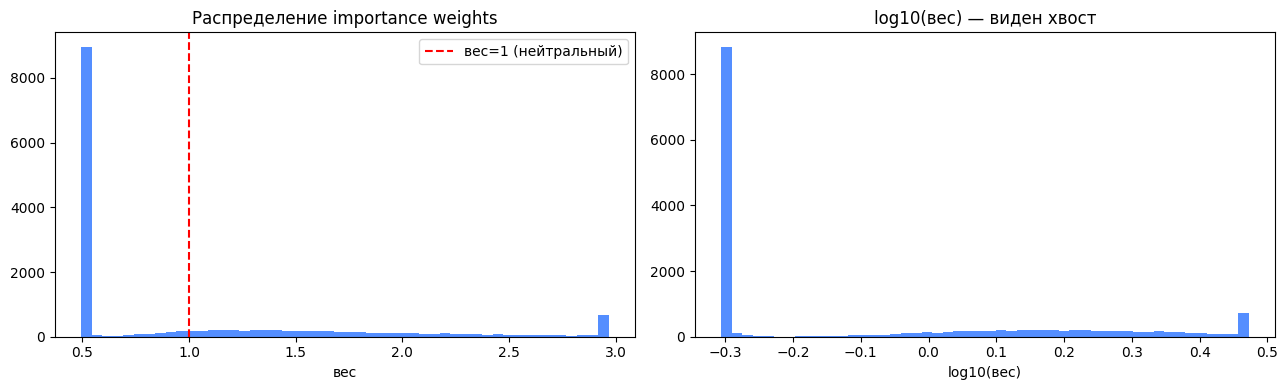

In [28]:
# Распределение весов визуализируем гистограммой — виден ли длинный хвост тяжёлых весов?

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(w_train, bins=50, color="#0B5FFF", alpha=0.7)
axes[0].axvline(1.0, color="red", linestyle="--", label="вес=1 (нейтральный)")
axes[0].set_title("Распределение importance weights")
axes[0].set_xlabel("вес"); axes[0].legend()

# log-шкала для хвоста
axes[1].hist(np.log10(w_train), bins=50, color="#0B5FFF", alpha=0.7)
axes[1].set_title("log10(вес) — виден хвост")
axes[1].set_xlabel("log10(вес)")
plt.tight_layout()
plt.show()

In [29]:
# sanity-check: похожи ли высоковесные магазины на holdout

# Магазины train с топ-весами должны быть ближе к holdout по дрейфующим фичам
train_w = train.copy()
train_w["imp_weight"] = w_train

top_w = train_w.nlargest(int(len(train_w) * 0.1), "imp_weight")  # топ-10% по весу

print("Сравнение по топ-дрейфующим фичам (medians):")
for col in ["TRADING_PATCH_SCORE", "HUFFRELATIVEFAMILIES", "TOTAL_RANK_COMPS_CANNIBALS"]:
    print(f"  {col}:")
    print(f"     весь train: {train[col].median():.4f}")
    print(f"     топ-вес 10%: {top_w[col].median():.4f}")
    print(f"     holdout:     {holdout[col].median():.4f}")

Сравнение по топ-дрейфующим фичам (medians):
  TRADING_PATCH_SCORE:
     весь train: 0.0314
     топ-вес 10%: 0.0136
     holdout:     0.0052
  HUFFRELATIVEFAMILIES:
     весь train: 0.8800
     топ-вес 10%: 0.8300
     holdout:     0.8200
  TOTAL_RANK_COMPS_CANNIBALS:
     весь train: 3.0000
     топ-вес 10%: 4.0000
     holdout:     4.0000


## Итог диагностики дрейфа

**Двойной дрейф:**

1. **MONTH_COUNT** — детерминированная метка времени (диапазоны train/val/holdout
   не пересекаются: 37-318 / 13-36 / 1-12 мес). Adversarial с ним = AUC 1.0.
   → ДРОП (это leak метки среза, не признак).
2. **Covariate shift по бизнес-фичам** — без MONTH_COUNT AUC всё ещё 0.963.
   Сильный многомерный сдвиг.

**Природа covariate shift (PSI train→holdout):**

- Сильный (PSI>0.25): TRADING_PATCH_SCORE (0.705).
- Умеренный: каннибализация/насыщенность (TOTAL_RANK_COMPS_CANNIBALS,
  HUFFRELATIVEFAMILIES, DENSITY_FAMILY_TYPE).
- 44 фичи univariate-стабильны, но в комбинации дают AUC 0.963.
- Соответствует ТЗ: новые магазины в насыщенных зонах, другие форматы.

**Concept drift:** 
слабый в наблюдаемой зоне (corr(MONTH_COUNT, TARGET_1)=−0.056),
но в зоне holdout (<1 года) не наблюдаем — таргета нет.

**Importance weights:**
 рассчитаны (density-ratio, смягчение **0.25, клип [0.5,3]).
НО при AUC 0.963 распределение бимодально (57% у нижнего клипа) — эффективный
размер выборки падает. Польза НЕ гарантирована → проверяем эмпирически на val
в baseline. При сильном дрейфе reweighting структурно ограничен.

**Стратегия для baseline:**

- Дроп MONTH_COUNT.
- Главная ставка: drift-robust фичи + monotone constraints (причинные связи
  устойчивее дрейфа), а не reweighting.
- Importance weights — опционально, решается на val.
- log1p(target), оптимизация под MAPE.